# 第一阶段：STEMNIST 原始压力 Conv-SNN 基线

本笔记本完成参数定义、数据准备、固定划分、数据检查、模型训练、验证、测试和可视化。默认启用冒烟测试，只处理少量真实样本；将 `SMOKE_TEST` 改为 `False` 后，才会依次进行 20 步和 240 步的完整训练。

## 1. 导入模块并确定目录

下面的目录判断同时支持从项目根目录或 `first_stage/code` 目录启动笔记本。

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
from torch import nn

# 自动定位代码目录，避免依赖启动位置
current_dir = Path.cwd().resolve()
if current_dir.name == "code" and current_dir.parent.name == "first_stage":
    CODE_DIR = current_dir
else:
    CODE_DIR = (current_dir / "first_stage" / "code").resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

FIRST_STAGE_DIR = CODE_DIR.parent
DATA_ROOT = FIRST_STAGE_DIR / "STEMNIST"
OUTPUT_ROOT = FIRST_STAGE_DIR / "outputs"

from data import (
    INDEX_TO_LABEL,
    STEMNISTDataset,
    aggregate_pressure_time,
    build_manifest,
    create_stratified_splits,
    download_and_extract_stemnist,
    read_pressure_array,
)
from model import ConvSNN, build_model
from utils import (
    compare_single_and_multi_step,
    create_dataloaders,
    evaluate,
    fit,
    load_checkpoint,
    network_state_is_reset,
    plot_class_distribution,
    plot_confusion_matrix,
    plot_pressure_sequence,
    plot_training_history,
    save_evaluation,
    select_device,
    set_random_seed,
)


## 2. 定义实验参数

冒烟模式对每种时间步设置只训练一个批次和一个 epoch，用于验证完整流程。完整模式使用计划规定的 50 个 epoch、batch size 64、Adam 优化器和随机种子 42。

In [2]:
# 首次检查保持为 True，正式训练前再改为 False
SMOKE_TEST = True
SEED = 42
TIME_STEPS_LIST = [20, 240]
FULL_EPOCHS = 50
FULL_BATCH_SIZE = 64
SMOKE_EPOCHS = 1
SMOKE_BATCH_SIZE = 2
LEARNING_RATE = 0.005
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
TAU = 10.0
NUM_WORKERS = 0
BACKEND = "torch"

mode_name = "smoke" if SMOKE_TEST else "full"
epochs = SMOKE_EPOCHS if SMOKE_TEST else FULL_EPOCHS
batch_size = SMOKE_BATCH_SIZE if SMOKE_TEST else FULL_BATCH_SIZE
max_train_batches = 1 if SMOKE_TEST else None
max_eval_batches = 1 if SMOKE_TEST else None
device = select_device()
set_random_seed(SEED)

COMMON_OUTPUT_DIR = OUTPUT_ROOT / mode_name / "common"
COMMON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"运行模式：{mode_name}")
print(f"计算设备：{device}")


运行模式：smoke
计算设备：cpu


## 3. 下载、校验并建立样本清单

程序会校验压缩包 MD5，确认 7,700 个原始样本、35 个类别、每类 220 个样本，以及 `[240,16,16]` 和 `uint8` 数据格式。已经生成的清单会直接复用。

In [3]:
archive_path, extracted_root = download_and_extract_stemnist(
    DATA_ROOT,
    download_if_missing=True,
)
manifest = build_manifest(
    extracted_root,
    DATA_ROOT / "cache" / "manifest.csv",
    strict=True,
)

print(f"压缩包：{archive_path}")
print(f"样本数：{len(manifest)}")
print(f"类别数：{manifest['label'].nunique()}")
print(f"参与者属性取值数：{manifest['participant_id'].nunique()}")
print(f"数值范围：{manifest['minimum'].min()} 到 {manifest['maximum'].max()}")
display(manifest.head())


警告：发现 25 个样本的 HDF5 参与者属性与文件名不一致；清单按 HDF5 属性记录。
警告：发现 40 个样本的 HDF5 重复次数属性与文件名不一致；清单按 HDF5 属性记录。
压缩包：C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\first_stage\STEMNIST\STEMNIST Dataset.zip
样本数：7700
类别数：35
参与者属性取值数：35
数值范围：64 到 255


,sample_id,participant_id,label,label_index,repetition,filename_participant_id,filename_label,filename_repetition,participant_metadata_matches_filename,label_metadata_matches_filename,repetition_metadata_matches_filename,raw_file_path,dataset_key,shape,dtype,minimum,maximum,sampling_rate,capture_time
0,AT_A_1,AT,A,0,1,AT,A,1,True,True,True,C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\fi...,pressure_data,"[240, 16, 16]",uint8,77,255,120,20250813_163937
1,AT_A_10,AT,A,0,10,AT,A,10,True,True,True,C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\fi...,pressure_data,"[240, 16, 16]",uint8,77,255,120,20251022_190625
2,AT_A_2,AT,A,0,2,AT,A,2,True,True,True,C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\fi...,pressure_data,"[240, 16, 16]",uint8,78,255,120,20251014_223743
3,AT_A_3,AT,A,0,3,AT,A,3,True,True,True,C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\fi...,pressure_data,"[240, 16, 16]",uint8,77,255,120,20251014_224119
4,AT_A_4,AT,A,0,4,AT,A,4,True,True,True,C:\Users\Fortyfour\Desktop\SNN_for_STEMNIST\fi...,pressure_data,"[240, 16, 16]",uint8,78,255,120,20251014_225312


## 4. 生成随机种子 42 的固定分层划分

第一次按类别分层划出 20% 测试集，再从剩余部分分层划出 20% 验证集，最终得到 4,928 个训练样本、1,232 个验证样本和 1,540 个测试样本。

划分数量：{'train': 4928, 'val': 1232, 'test': 1540}


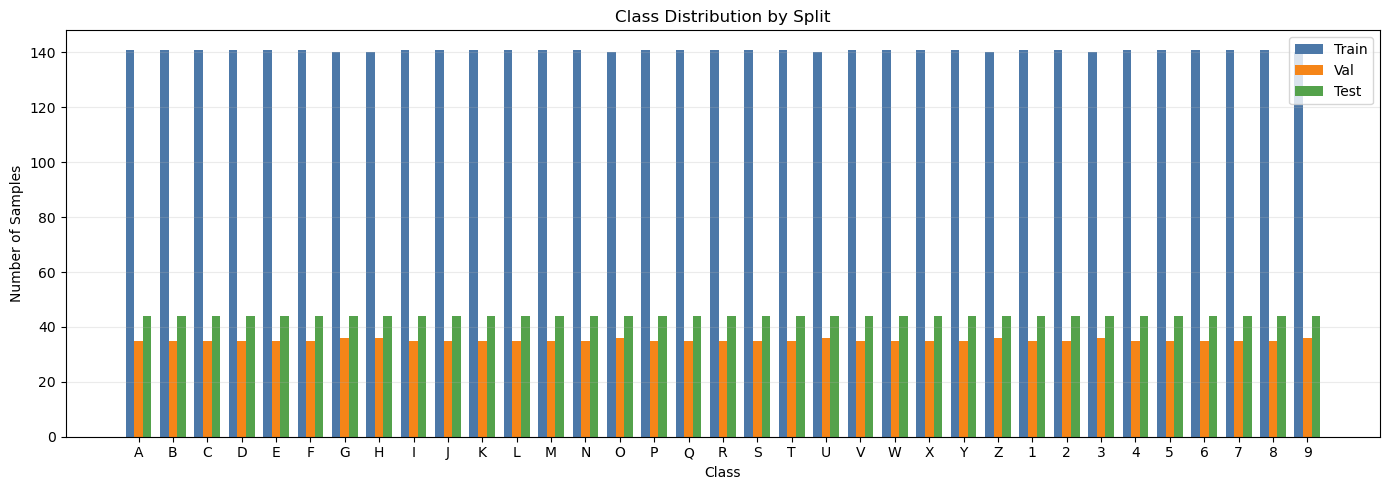

In [4]:
splits = create_stratified_splits(
    manifest,
    DATA_ROOT / "cache" / "split_seed42.json",
    seed=SEED,
)
split_sizes = {name: len(records) for name, records in splits.items()}
print(f"划分数量：{split_sizes}")

plot_class_distribution(
    splits,
    save_path=COMMON_OUTPUT_DIR / "class_distribution.png",
)


## 5. 查看一个原始压力样本

这里展示均匀抽取的六个时间点，用于直观确认时间维和空间维没有交换。图中的文字全部使用英文。

样本：AT_1_10，张量形状：(240, 1, 16, 16)


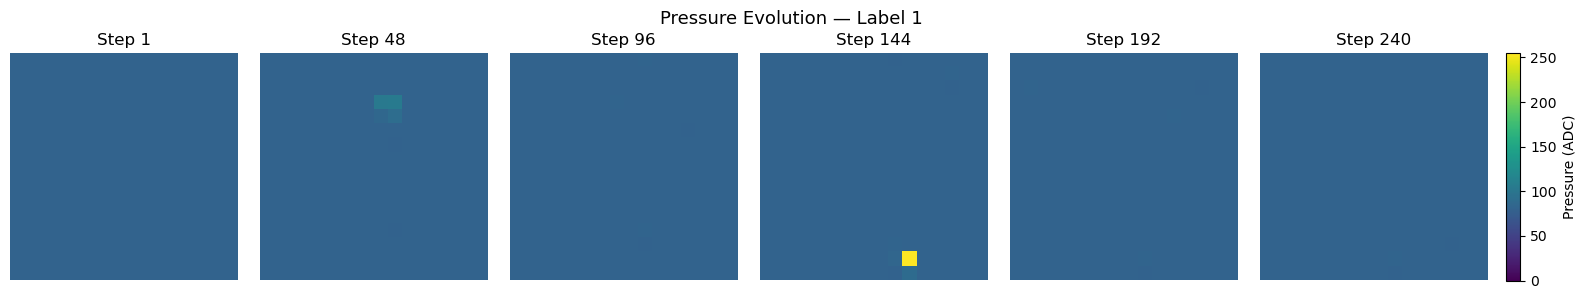

In [5]:
preview_dataset = STEMNISTDataset(splits["train"].iloc[:1], time_steps=240)
preview_sample, preview_label_index, preview_sample_id = preview_dataset[0]
print(f"样本：{preview_sample_id}，张量形状：{tuple(preview_sample.shape)}")
plot_pressure_sequence(
    preview_sample,
    label=INDEX_TO_LABEL[preview_label_index],
    save_path=COMMON_OUTPUT_DIR / "pressure_sequence.png",
)


## 6. 训练、验证、测试与可视化

下面依次执行 20 步和 240 步设置。每种设置都会检查张量形状、20 步均值聚合、6,379 个模型参数、单步与多步一致性、有限损失与梯度，以及 batch 之间的状态复位。测试集只在恢复验证集最优模型后评估。


===== 20 个时间步 =====
批次形状：(2, 20, 1, 16, 16)
模型参数量：6379
单步/多步最大绝对误差：0.00000000


Epoch 001/001 | Train loss 4.6170 | Val loss 3.7230 | Val accuracy 0.0000 | Val macro-F1 0.0000


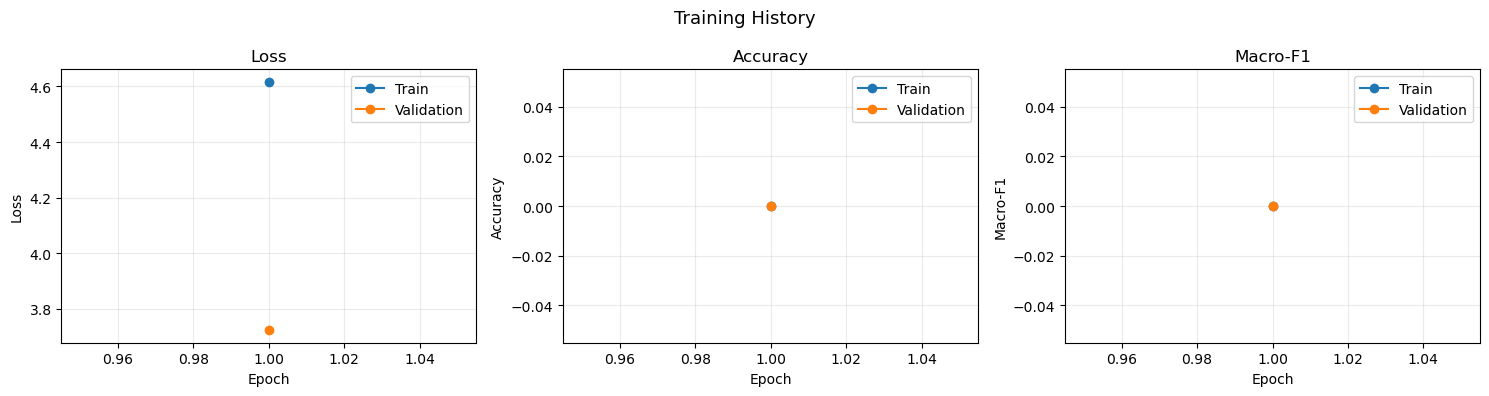

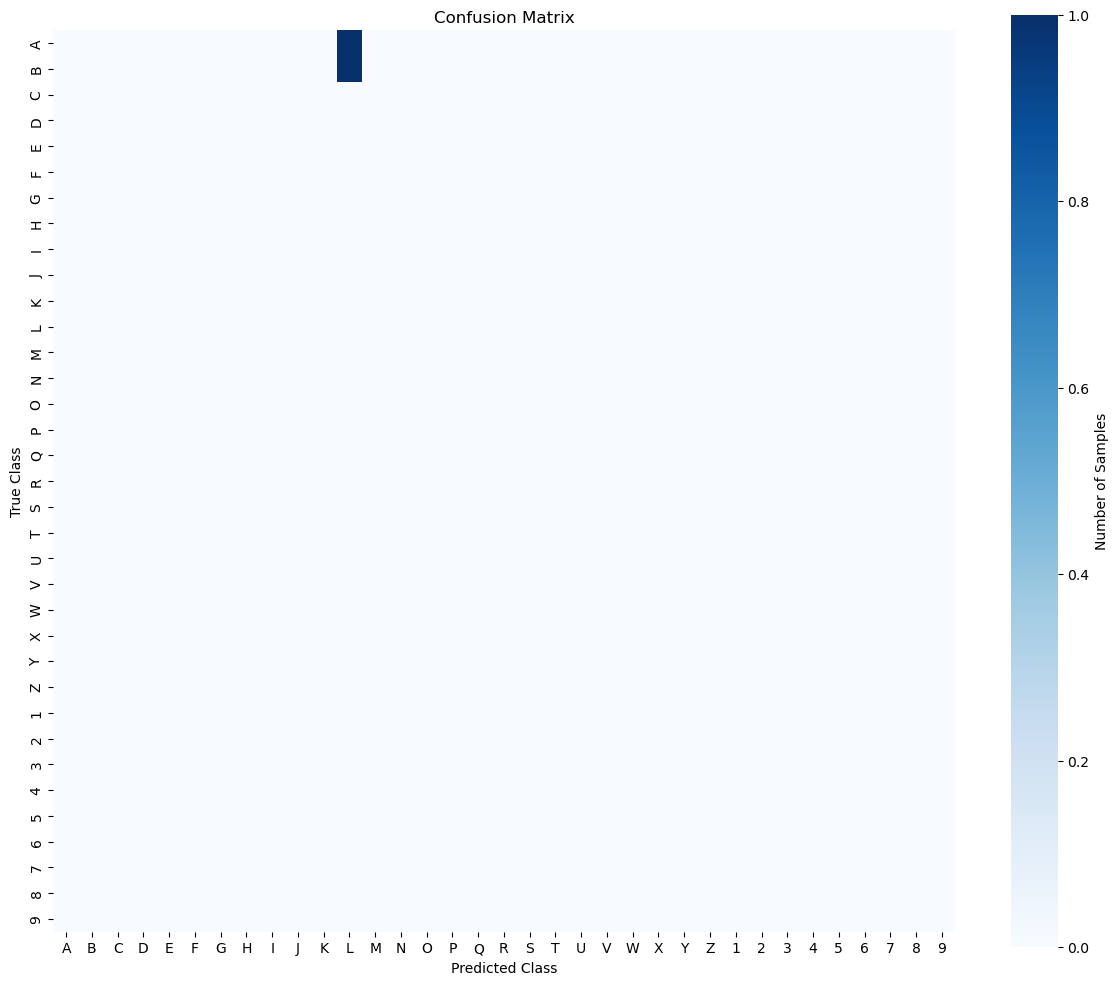


===== 240 个时间步 =====
批次形状：(2, 240, 1, 16, 16)
模型参数量：6379


单步/多步最大绝对误差：0.00000000


Epoch 001/001 | Train loss 54.5636 | Val loss 18.5013 | Val accuracy 0.0000 | Val macro-F1 0.0000


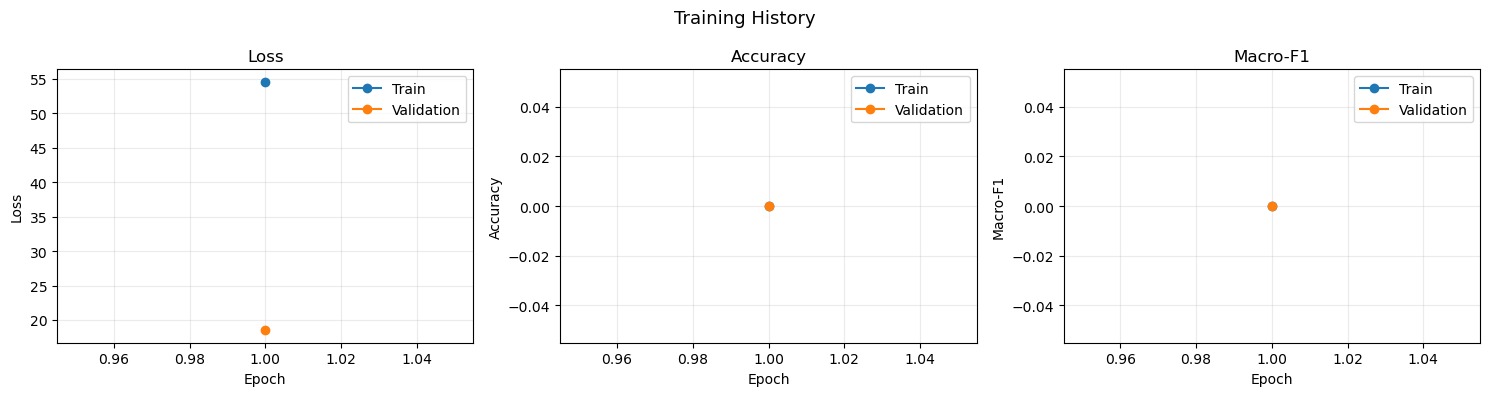

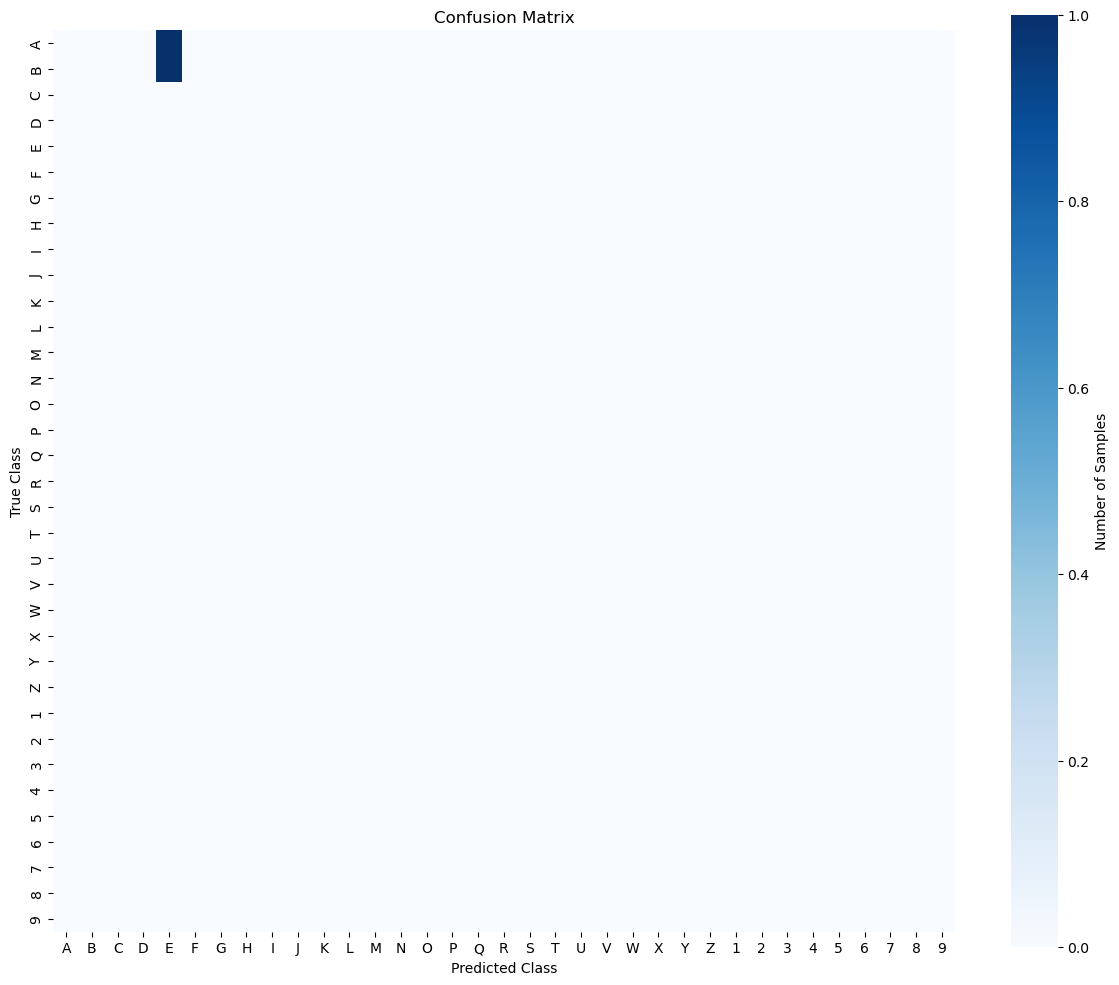

,time_steps,mode,test_loss,test_accuracy,test_macro_f1,tested_samples,state_reset,step_mode_max_error
0,20,smoke,3.796921,0.0,0.0,2,True,0.0
1,240,smoke,25.000065,0.0,0.0,2,True,0.0


In [6]:
summary_rows = []

for time_steps in TIME_STEPS_LIST:
    print(f"\n===== {time_steps} 个时间步 =====")
    run_output_dir = OUTPUT_ROOT / mode_name / f"{time_steps}_steps"
    run_output_dir.mkdir(parents=True, exist_ok=True)

    loaders, selected_records = create_dataloaders(
        splits=splits,
        time_steps=time_steps,
        batch_size=batch_size,
        seed=SEED,
        num_workers=NUM_WORKERS,
        smoke_test=SMOKE_TEST,
        smoke_samples_per_class={"train": 2, "val": 1, "test": 1},
    )

    # 检查 DataLoader 输出顺序和形状
    sample_batch, label_batch, sample_id_batch = next(iter(loaders["train"]))
    expected_shape = (sample_batch.shape[0], time_steps, 1, 16, 16)
    assert tuple(sample_batch.shape) == expected_shape
    print(f"批次形状：{tuple(sample_batch.shape)}")

    # 直接对照原始数据，验证 20 步聚合没有交换维度
    dataset_sample, _, dataset_sample_id = loaders["train"].dataset[0]
    sample_record = selected_records["train"].set_index("sample_id").loc[dataset_sample_id]
    raw_pressure = read_pressure_array(sample_record["raw_file_path"])
    expected_pressure = aggregate_pressure_time(raw_pressure, time_steps)
    assert np.allclose(dataset_sample[:, 0].numpy(), expected_pressure)

    model = build_model(
        num_classes=35,
        dropout=DROPOUT,
        tau=TAU,
        backend=BACKEND,
    ).to(device)
    assert model.parameter_count() == ConvSNN.EXPECTED_PARAMETER_COUNT
    print(f"模型参数量：{model.parameter_count()}")

    # 使用一个真实样本比较单步循环和多步模式
    comparison_input = sample_batch[:1].permute(1, 0, 2, 3, 4).contiguous().to(device)
    step_comparison = compare_single_and_multi_step(model, comparison_input)
    assert step_comparison["matches"]
    print(f"单步/多步最大绝对误差：{step_comparison['maximum_absolute_error']:.8f}")

    config = {
        "smoke_test": SMOKE_TEST,
        "seed": SEED,
        "time_steps": time_steps,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT,
        "tau": TAU,
        "backend": BACKEND,
        "normalization": False,
        "split_seed": SEED,
    }
    history = fit(
        model=model,
        loaders=loaders,
        device=device,
        output_dir=run_output_dir,
        config=config,
        epochs=epochs,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        max_train_batches=max_train_batches,
        max_eval_batches=max_eval_batches,
    )
    assert network_state_is_reset(model)

    load_checkpoint(model, run_output_dir / "best.pt", device)
    criterion = nn.CrossEntropyLoss()
    test_metrics = evaluate(
        model,
        loaders["test"],
        criterion,
        device,
        max_batches=max_eval_batches,
        detailed=True,
    )
    assert network_state_is_reset(model)
    save_evaluation(test_metrics, run_output_dir, prefix="test")

    plot_training_history(
        history,
        save_path=run_output_dir / "training_history.png",
    )
    plot_confusion_matrix(
        test_metrics["confusion_matrix"],
        save_path=run_output_dir / "confusion_matrix.png",
    )

    summary_rows.append(
        {
            "time_steps": time_steps,
            "mode": mode_name,
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "tested_samples": test_metrics["samples"],
            "state_reset": network_state_is_reset(model),
            "step_mode_max_error": step_comparison["maximum_absolute_error"],
        }
    )

summary = pd.DataFrame(summary_rows)
summary.to_csv(
    OUTPUT_ROOT / mode_name / "summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(summary)


## 7. 结果说明

冒烟模式的准确率没有统计意义，它只用于确认下载、读取、聚合、前向、反向、状态复位、checkpoint、测试和绘图流程能够完整运行。正式结果应在将 `SMOKE_TEST=False` 后重新执行整个笔记本获得。